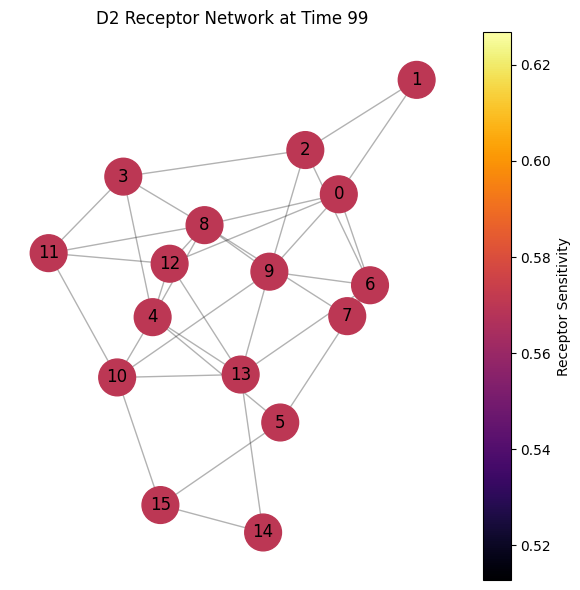

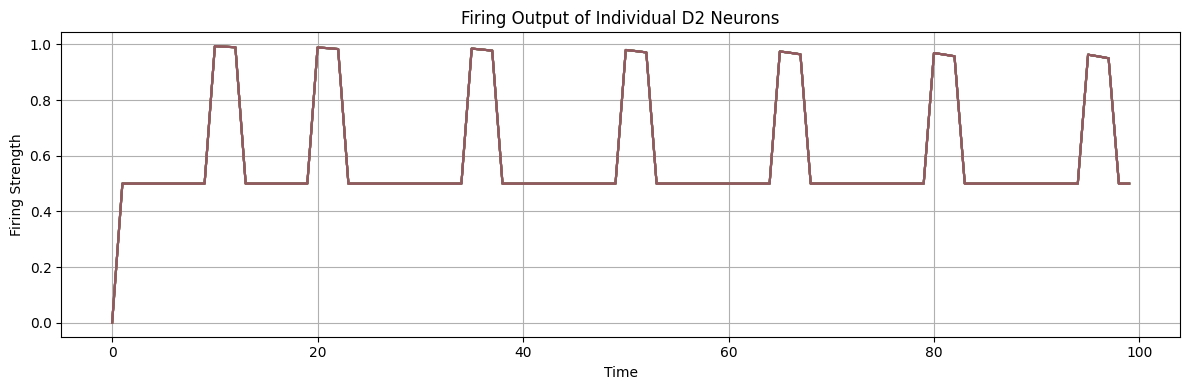

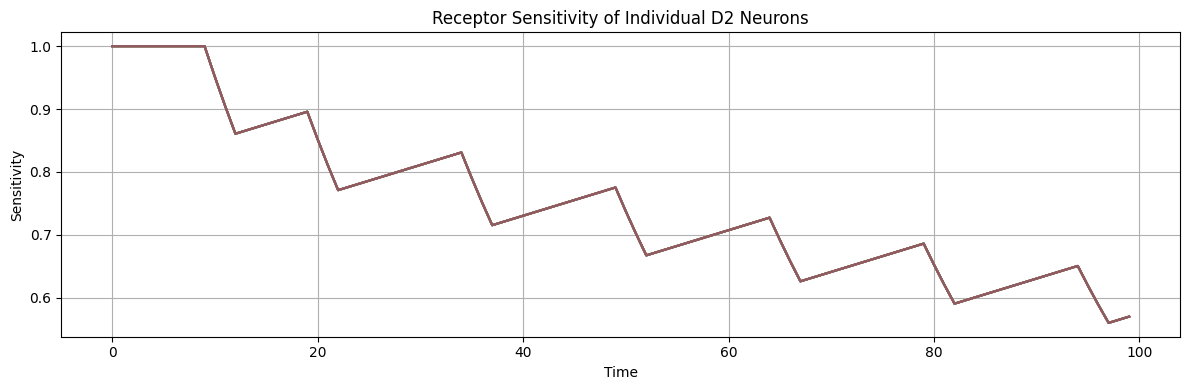

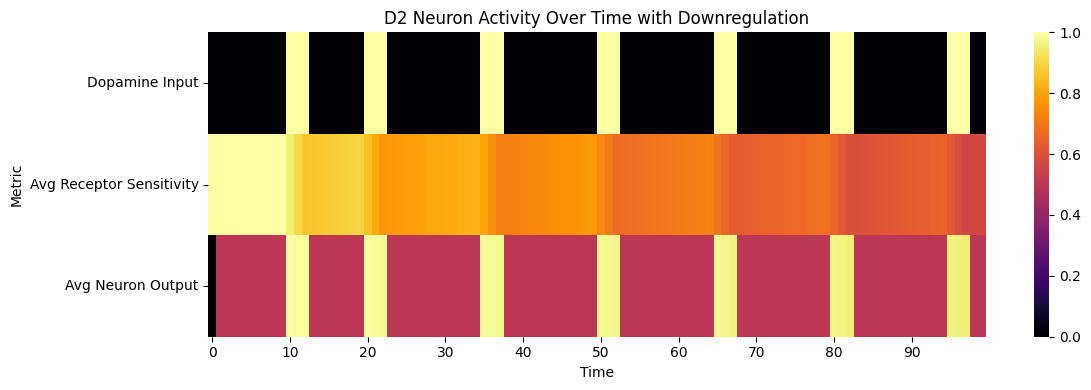

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import networkx as nx

# Simulating parameters 
timesteps = 100
num_neurons = 16 # My number of neurons for now later I will be adding more :D 

# Dopamine bursts 
dopamine_bursts = np.zeros(timesteps)

# Dopamine bursts at specific time intervals 
burst_intervals = [10, 20, 35, 50, 65, 80, 95]
for i in burst_intervals:
    dopamine_bursts[i:i+3] = 1.0 

# Sensativity and exposure 
sensitivity = np.ones((num_neurons, timesteps))
firing_output = np.zeros((num_neurons, timesteps))
exposure = np.zeros(num_neurons)

decay_rate = 0.01 # How fast receptor downregulates per burst

# Sigmoind function 
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

# Neuron response 
# Simulation Loop 
for t in range(1, timesteps):
    dopamine_input = dopamine_bursts[t]

    for n in range(num_neurons):
        exposure[n] += dopamine_input

        # Downregulate based on cumulative exposure
        if dopamine_input > 0.8:
            sensitivity[n, t] = sensitivity[n, t-1] * np.exp(-0.05)
        else:
            sensitivity[n, t] = min(1.0, sensitivity[n, t-1] + 0.005)

        # Neuron firing
        firing_output[n, t] = sigmoid(5 * dopamine_input * sensitivity[n, t-1])


# Vizualizations for NETWORKX BEGINS here 
# -------------------------------------------------------------


# Make a neuron networklike representation of the D2 neurons 
# Number of neurons can be adjusted above 

final_time = timesteps - 1
node_colors = sensitivity[:, final_time]
node_sizes = 300 + (node_colors * 700) 

# Simple Network
G = nx.Graph()
for n in range(num_neurons):
    G.add_node(n)

import random
for i in range(num_neurons):
    for j in range(i + 1, num_neurons):
        if random.random() < 0.2:
            G.add_edge(i, j)

# For edges
for n in range(num_neurons - 1):
    G.add_edge(n, n + 1)

# Layout for visualization
# Spring layout gives a networklike look 
# First layout was too linear 
pos = nx.spring_layout(G, seed=42)


# Draw the network
plt.figure(figsize=(6, 6))
nodes = nx.draw_networkx_nodes(G, pos, node_color=node_colors, cmap='inferno', node_size=node_sizes)
nx.draw_networkx_edges(G, pos, alpha=0.3)
nx.draw_networkx_labels(G, pos)

plt.title(f'D2 Receptor Network at Time {final_time}')
plt.colorbar(nodes, label='Receptor Sensitivity')
plt.axis('off')
plt.tight_layout()
plt.savefig("Plots2/Neuron Network.png")
plt.show()

# Average across neurons for network-level view
avg_sensitivity = sensitivity.mean(axis=0)
avg_firing = firing_output.mean(axis=0)

# Create a heatmap matrix
data_matrix = np.vstack([dopamine_bursts, avg_sensitivity, avg_firing])
labels = ['Dopamine Input', 'Avg Receptor Sensitivity', 'Avg Neuron Output']


# Convert to DataFrame for better plotting
df = pd.DataFrame(data_matrix, index=labels)

# End of NETWORKX STUFF
# ---------------------------------------------------------------



# Firing output of individual neurons 
# Not sure if I will keep this yet we will see :D 
plt.figure(figsize=(12, 4))
for n in range(num_neurons):
    plt.plot(firing_output[n], label=f'Neuron {n+1}', alpha=0.6)
plt.title('Firing Output of Individual D2 Neurons')
plt.xlabel('Time')
plt.ylabel('Firing Strength')
plt.grid(True)
plt.tight_layout()
plt.savefig("Plots2/Firing output of individual neurons.png")
plt.show()

# Plot for receptor sensativity of individual D2 Neurons 
plt.figure(figsize=(12, 4))
for n in range(num_neurons):
    plt.plot(sensitivity[n], label=f'Neuron {n+1}', alpha=0.6)
plt.title('Receptor Sensitivity of Individual D2 Neurons')
plt.xlabel('Time')
plt.ylabel('Sensitivity')
plt.grid(True)
plt.tight_layout()
plt.savefig("Plots2/D2 Downregulation 2.png")
plt.show()

# Heatmap sensativity overtime 
plt.figure(figsize=(12, 4))
sns.heatmap(df, cmap='inferno', cbar=True, xticklabels=10, yticklabels=labels)
plt.title("D2 Neuron Activity Over Time with Downregulation")
plt.xlabel("Time")
plt.ylabel("Metric")
plt.tight_layout()
plt.savefig("Plots2/D2 Heatmap.png")
plt.show()